*** This Code is for Extracting ship information from NovaSAR images and their corresponding AIS data

In [1]:
# Import dependencies

import os
import numpy as np
import math
from datetime import datetime, date
import matplotlib.pyplot as plt


In [2]:
import rasterio as rio

# NovaSAR images

In [3]:
head_dir = "/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/"
data_dir = "Airbus_2024Feb23"
# data_dir = "Airbus_2024Jan11"
data_dir = "Airbus_2024Jun13"

#### Tif images

In [4]:
import os

tif_files = []
for root, dirs, files in os.walk(head_dir+data_dir):
    for file in files:
        if file.lower().endswith('.tif'):         
            full_path = os.path.join(root, file)
            # Skip if "Extracted_Kelvin_Waves" is in the path
            if "Extracted" not in full_path:
                tif_files.append(full_path)


tif_files = [f for f in tif_files if not os.path.basename(f).startswith('QL')] # Exclude files starting with 'QL' [These are low resolution files only for visualisation]
print(f"Found {len(tif_files)} tif files.")
tif_files

Found 441 tif files.


['/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082440_HH_1/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082446_HH_2/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082452_HH_3/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082457_HH_4/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082503_HH_5/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082508_HH_6/image_HH.tif',
 '/mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_g

In [53]:
tii = 2 # Index of the tif file to process

In [54]:
# Load metadata to generate geo tranformation using tiepoints and sampling info
import xml.etree.ElementTree as ET

file_path = f"{tif_files[tii][:-12]}metadata.xml"
tree = ET.parse(file_path)
root = tree.getroot()

'20240411_082452'

In [90]:
# Find the data acquisition date from the metadata XML file:
from datetime import datetime

# srcattr_info_elem = root.find(".//Source_Attributes")
# # Extract RawDataStartTime
# elem = srcattr_info_elem.find(".//RawDataStartTime")
# acqdate0 = elem.text if elem is not None else None
# # Change the date format from 'YYYY-MM-DD HH:MM:SS.ssssss' to 'DD/MM/YYYY HH:MM:SS'
# dt = datetime.strptime(acqdate0, '%Y-%m-%d %H:%M:%S.%f')

acqdate0 = f"20{tif_files[tii][-31:-18]}"
dt = datetime.strptime(acqdate0, '%Y%m%d_%H%M%S')

acqdate = dt.strftime('%d/%m/%Y %H:%M:%S')
print("Raw Data Start Time:", acqdate)

Raw Data Start Time: 11/04/2024 08:24:52


In [56]:
# Find the "geographicInformation" element in the XML metadata
geo_info_elem = root.find(".//geographicInformation")

# Extract the text of the "EllipsoidName" element from geo_info_elem
ellipsoid_elem = geo_info_elem.find(".//EllipsoidName")
ellipsoid = ellipsoid_elem.text if ellipsoid_elem is not None else None
print("Ellipsoid Name:", ellipsoid)



Ellipsoid Name: WGS84


In [57]:
# Extracting SampledLineSpacing and SampledPixelSpacing from Image_Attributes

# Find the "Image_Attributes" element in the XML metadata
im_attr_info_elem = root.find(".//Image_Attributes")

# Extract SampledLineSpacing
elem = im_attr_info_elem.find(".//SampledLineSpacing")
gsd_line = elem.text if elem is not None else None
print("Sampled Line Spacing:", gsd_line)

# Extract SampledPixelSpacing
elem = im_attr_info_elem.find(".//SampledPixelSpacing")
gsd_pixel = elem.text if elem is not None else None
print("Sampled Pixel Spacing:", gsd_pixel)

elem = geo_info_elem.find(".//SemiMajorAxis")
SemiMajorAxis_name = elem.text if elem is not None else None
print("SemiMajorAxis:", SemiMajorAxis_name)

elem = geo_info_elem.find(".//SemiMinorAxis")
SemiMinorAxis_name = elem.text if elem is not None else None
print("SemiMinorAxis:", SemiMinorAxis_name)

Sampled Line Spacing: 2.50
Sampled Pixel Spacing: 2.50
SemiMajorAxis: 6378137.0
SemiMinorAxis: 6356752.3


In [ ]:
# Extract tie point information from the "geographicInformation" element
lat_all = []
lon_all = []
tiepoints = []
for tp in geo_info_elem.findall(".//TiePoint"):
    line = tp.findtext("Line")
    pixel = tp.findtext("Pixel")
    lat = tp.findtext("Latitude")
    lon = tp.findtext("Longitude")
    height = tp.findtext("Height")
    tiepoints.append( rio.control.GroundControlPoint( row=int(line), col=int(pixel), x=float(lon), y=float(lat)) )

    lat_all.append(float(lat))
    lon_all.append(float(lon))

lat_min = min(lat_all)
lon_min = min(lon_all)
lat_max = max(lat_all)
lon_max = max(lon_all)
print(f"Lat extent: ({lat_min}, {lat_max}), Lon extent: ({lon_min}, {lon_max})")

# Display the extracted tiepoints
for tp in tiepoints:
    print(tp)

Lat extent: (54.42359835, 54.81632701), Lon extent: (11.26166182, 11.73151044)
GroundControlPoint(row=0, col=0, x=11.73151044, y=54.47637723, id='40266b75-311b-40ee-a0d7-cf26611f8d41')
GroundControlPoint(row=0, col=1582, x=11.67376342, y=54.46588574, id='3be605b1-c91c-4e6b-b4cb-04dda92ef411')
GroundControlPoint(row=0, col=3164, x=11.6160244, y=54.45536276, id='c9ac52aa-e4f2-4789-ac8e-69e3a5482d94')
GroundControlPoint(row=0, col=4747, x=11.55825406, y=54.44480108, id='e0798149-a6b6-4c4d-8ed2-cbd91c3cf733')
GroundControlPoint(row=0, col=6329, x=11.500531, y=54.43421504, id='314ad3d5-b03c-42d1-a2bb-ddeb6c627f75')
GroundControlPoint(row=0, col=7911, x=11.44282078, y=54.42359835, id='2a21a5db-22c0-4814-b569-dec4df6c27d9')
GroundControlPoint(row=3165, col=0, x=11.69603104, y=54.54439462, id='63b0c9c5-67b5-4ef9-86f9-c0ec01c1cbf8')
GroundControlPoint(row=3165, col=1582, x=11.6381739, y=54.53388586, id='80c8ff39-bdb3-4570-ab9c-acfc60b5abc2')
GroundControlPoint(row=3165, col=3164, x=11.58032592,

CRS and transform

In [ ]:
# Generate CRS and transform using ellipsoid and tiepoints information extracted from the metadata XML file:
from rasterio.crs import CRS

# Use ellipsoid parameters for CRS, fallback to WGS84 if not available
if ellipsoid == "WGS84":
    crs = CRS.from_epsg(4326)
else:
    crs = CRS.from_string(f"+proj=longlat +a={SemiMajorAxis_name} +b={SemiMinorAxis_name} +no_defs")

transform = rio.transform.from_gcps(tiepoints)
print("Updated Transform:", transform)

Updated Transform: |-0.00,-0.00, 11.73|
|-0.00, 0.00, 54.48|
| 0.00, 0.00, 1.00|


Warning 1: TIFFFetchNormalTag:ASCII value for tag "ImageDescription" contains null byte in value; value incorrectly truncated during reading due to implementation limitations


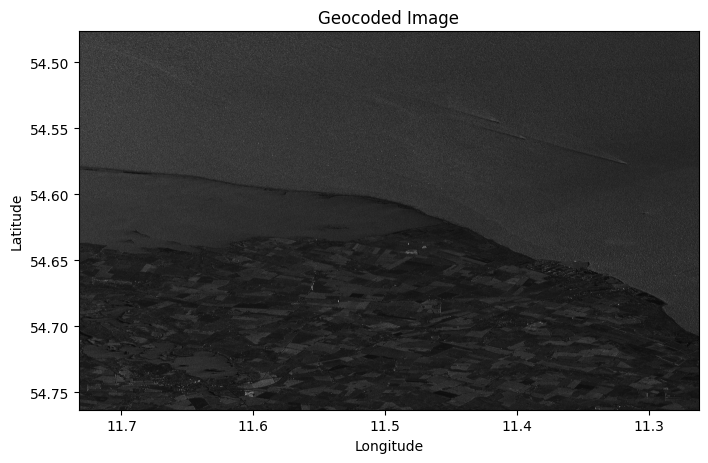

In [127]:
import rasterio.plot
src = rio.open(tif_files[tii])
im = src.read(1)
im_uint8 = (255*im/1500).astype(np.uint8)
fig, ax = plt.subplots(figsize=(8, 8))
rio.plot.show(im, ax=ax, transform=transform, cmap='gray', vmin=0, vmax=1500)
ax.set_title("Geocoded Image")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

#### AIS

In [94]:
# AIS data:
# ais_name = f"aisdk-{acqdate0[:10]}"  # Extract the date part (YYYY-MM-DD)       
ais_name = f"aisdk-{acqdate0[:8][:4]}-{acqdate0[:8][4:6]}-{acqdate0[:8][6:8]}"  # Extract the date part (YYYY-MM-DD)       
csv_dir = f"AIS_dataset/{ais_name}/{ais_name}.csv" 
# csv_dir = r"E:\AssenSAR\CSP LIDAR Data\NovaSAR\AIS_dataset\aisdk-2024-04-15\aisdk-2024-04-15.csv" 

In [63]:
# import pandas as pd

# # Load only the first 100 rows of a CSV file
# df_partial = pd.read_csv(head_dir+csv_dir, nrows=150000)
# df_partial[9000:15000]  # Display rows 100 to 1100

In [97]:
import pandas as pd
from datetime import datetime, timedelta

timestamp_col = '# Timestamp'
start_time    = ( datetime.strptime(acqdate, '%d/%m/%Y %H:%M:%S') - timedelta(seconds=1) ).strftime('%d/%m/%Y %H:%M:%S')
end_time      = ( datetime.strptime(acqdate, '%d/%m/%Y %H:%M:%S') + timedelta(seconds=1) ).strftime('%d/%m/%Y %H:%M:%S')
lat_col       = 'Latitude'
lon_col       = 'Longitude'

chunks = []
for chunk in pd.read_csv(head_dir+csv_dir, chunksize=500000):
    mask = (chunk[timestamp_col] >= start_time) & (chunk[timestamp_col] <= end_time) & \
           (chunk[lat_col] >= lat_min) & (chunk[lat_col] <= lat_max) & \
           (chunk[lon_col] >= lon_min) & (chunk[lon_col] <= lon_max)
    filtered = chunk[mask]
    if not filtered.empty:
        chunks.append(filtered)

AIS_image_df = pd.concat(chunks, ignore_index=True)
AIS_image_df

,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,ROT,SOG,COG,Heading,...,Length,Type of position fixing device,Draught,Destination,ETA,Data source type,A,B,C,D
0,11/04/2024 08:24:51,Class A,245258000,54.525982,11.372965,Under way using engine,0.0,14.3,107.6,110.0,...,170.0,GPS,9.0,PLGDY VIA NOK,12/04/2024 07:00:00,AIS,156.0,14.0,13.0,13.0
1,11/04/2024 08:24:51,Class A,245258000,54.525982,11.372965,Under way using engine,0.0,14.3,107.6,110.0,...,170.0,GPS,9.0,PLGDY VIA NOK,12/04/2024 07:00:00,AIS,156.0,14.0,13.0,13.0
2,11/04/2024 08:24:51,Class A,245258000,54.525982,11.372965,Under way using engine,0.0,14.3,107.6,110.0,...,170.0,GPS,9.0,PLGDY VIA NOK,12/04/2024 07:00:00,AIS,156.0,14.0,13.0,13.0
3,11/04/2024 08:24:51,Class A,209453000,54.634110,11.381472,Restricted maneuverability,NaN,0.0,278.8,NaN,...,60.0,GPS,2.6,RODBY HAVN,NaN,AIS,50.0,10.0,9.0,9.0
4,11/04/2024 08:24:51,Class A,209453000,54.634110,11.381472,Restricted maneuverability,NaN,0.0,278.8,NaN,...,60.0,GPS,2.6,RODBY HAVN,NaN,AIS,50.0,10.0,9.0,9.0
5,11/04/2024 08:24:51,Class A,212701000,54.624732,11.360080,Restricted maneuverability,NaN,2.4,225.1,226.0,...,48.0,Internal,2.9,DREDGING,19/05/2024 03:40:00,AIS,8.0,40.0,11.0,4.0
6,11/04/2024 08:24:51,Class A,212701000,54.624732,11.360080,Restricted maneuverability,NaN,2.4,225.1,226.0,...,48.0,Internal,2.9,DREDGING,19/05/2024 03:40:00,AIS,8.0,40.0,11.0,4.0
7,11/04/2024 08:24:51,Class A,209808000,54.657328,11.350060,Under way using engine,0.0,0.0,0.0,317.0,...,30.0,GPS,3.2,FEMERN BLT WRK VSL,11/03/2025 16:00:00,AIS,12.0,18.0,4.0,6.0
8,11/04/2024 08:24:51,Class A,209808000,54.657328,11.350060,Under way using engine,0.0,0.0,0.0,317.0,...,30.0,GPS,3.2,FEMERN BLT WRK VSL,11/03/2025 16:00:00,AIS,12.0,18.0,4.0,6.0
9,11/04/2024 08:24:51,Class A,209808000,54.657328,11.350060,Under way using engine,0.0,0.0,0.0,317.0,...,30.0,GPS,3.2,FEMERN BLT WRK VSL,11/03/2025 16:00:00,AIS,12.0,18.0,4.0,6.0


In [98]:
AIS_image_df.to_csv(f"{tif_files[tii][:-12]}/AIS.csv", index=False)
print(f"Saved AIS data to {tif_files[tii][:-12]}/AIS.csv")

Saved AIS data to /mnt/e/AssenSAR/CSP LIDAR Data/NovaSAR/Airbus_2024Jun13/NovaSAR_01_53540_grd_240411_082440_HH/NovaSAR_01_53540_grd_13_240411_082452_HH_3//AIS.csv


## Working with .SAFE file using SNAPPY

In [ ]:
from esa_snappy import ProductIO


In [5]:
p = ProductIO.readProduct("E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\Copernicus\S1A_IW_GRDH_1SDV_20230831T181434_20230831T181459_050123_06082E_0B83_COG.zip")
list(p.getBandNames())

['Amplitude_VV', 'Intensity_VV', 'Amplitude_VH', 'Intensity_VH']

## RasterIO

In [3]:
dir = "E:\\AssenSAR\\CSP LIDAR Data\\Sentinel Data Download\\GEE\Sentinel1_Images_ShipPath\\"
dir = "E:\\AssenSAR\\CSP LIDAR Data\\Sentinel Data Download\\GEE\Sentinel1_Images_CaldeyIsland\\"
im_name_all = [f for f in os.listdir(dir) if f.lower().endswith('.tif')]
im_name_all

['Sentinel1_S1A_IW_GRDH_1SDV_20220503T180606_20220503T180631_043050_052404_5D82_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220505T063942_20220505T064007_043072_0524BA_9119_DESCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220508T181422_20220508T181447_043123_052660_6311_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220512T063129_20220512T063154_043174_0527F9_36AA_DESCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220515T180607_20220515T180632_043225_052998_1A1E_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220517T063942_20220517T064007_043247_052A37_A933_DESCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220520T181423_20220520T181448_043298_052BAC_326E_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220527T180607_20220527T180632_043400_052EC7_F105_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220529T063944_20220529T064009_043422_052F64_B17A_DESCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_20220601T181424_20220601T181449_043473_0530DA_E670_ASCENDING.tif',
 'Sentinel1_S1A_IW_GRDH_1SDV_2022060

In [4]:
import rasterio as rio
im_path = dir + im_name_all[0]
src=rio.open(im_path)

im = src.read()#1, window=((5000, 15000), (15000, 25000)))
im.shape

(3, 780, 1114)

In [5]:
im.shape[2]#%(im.shape[2]//4+1)

1114

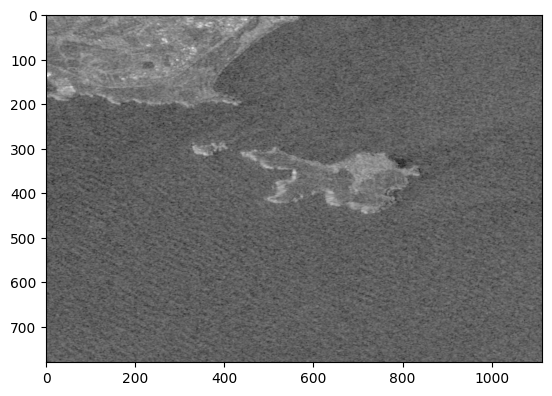

In [6]:
plt.imshow(im[0], cmap='gray')


In [7]:
# Function to export a subset of a raster image as a 512x512 window

def float_to_uint8(arr):
    """
    Rescale a float array to the range 0-255 and convert to uint8.
    """
    arr_min = np.nanmin(arr)
    arr_max = np.nanmax(arr)
    if arr_max == arr_min:
        return np.zeros_like(arr, dtype=np.uint8)
    scaled = (arr - arr_min) / (arr_max - arr_min) * 255
    return scaled.astype(np.uint8)

def export_subset(im_path, start_row=0, start_col=0, win_height=512, win_width=512, uint8=False, rgb='No', out_name="subset_output.tif"):
    """
    Exports a subset of a raster image as a 512x512 window.
    
    Parameters:
    - im_path: Path to the input raster image.
    - start_row: Starting row index for the window.
    - start_col: Starting column index for the window.
    - win_height: Height of the window.
    - win_width: Width of the window.
    - uint8: If True, converts the output to uint8 format.
    - rgb: If 'No', exports all bands (VV, VH, incidence angle); 
           if 'VV', repeats VV channel 3 times; 
           if 'VH', repeats VH channel 3 times;
           if 'all', [VV, VH, VV-VH]
    - out_name: Name of the output file.
    
    Returns:
    - None
    """
    from rasterio.windows import Window

    # Open the raster image
    with rio.open(im_path) as src:

        # Compute how much of the window is inside the image bounds
        read_height = min(win_height, src.height - start_row)
        read_width  = min(win_width, src.width - start_col)

        # Read the available portion
        window = Window( start_col, start_row, read_width, read_height )
        sub0 = src.read(window=window)

        if uint8:
            sub0[0:1, :, :] = float_to_uint8(sub0[0:1, :, :])
            sub0[1:2, :, :] = float_to_uint8(sub0[1:2, :, :])
            sub0[2:3, :, :] = float_to_uint8(sub0[2:3, :, :])

        if rgb == 'VV':
            sub0 = np.repeat(sub0[0:1, :, :], 3, axis=0)  # Repeat VV channel 3 times
        elif rgb == 'VH':
            sub0 = np.repeat(sub0[1:2, :, :], 3, axis=0)
        elif rgb == 'all':
            sub0 = np.concatenate((sub0[0:1, :, :], sub0[1:2, :, :], sub0[0:1, :, :] - sub0[1:2, :, :]), axis=0)
        elif rgb == 'No':
            pass

        # Check if the read dimensions match the desired window size:
        if read_height != win_height or read_width != win_width:
            # Pad with zeros to make it 512x512
            num_bands = sub0.shape[0]
            if uint8:
                sub = np.zeros( (num_bands, win_height, win_width), dtype=np.uint8 )
            else:
                sub = np.zeros( (num_bands, win_height, win_width), dtype=src.dtypes[0] )
            sub[:, :read_height, :read_width] = sub0
        else:
            sub = sub0

        # Adjust metadata:
        out_meta = src.meta.copy()
        out_meta.update({
            "height": win_height,
            "width": win_width,
            "transform": src.window_transform( Window(start_col, start_row, win_width, win_height) )
        })
        if uint8:
            out_meta["dtype"] = "uint8"

    # Write the output:
    with rio.open(out_name, "w", **out_meta) as dest:
        dest.write(sub)


In [ ]:
# Parameters
win_height, win_width = im.shape[1]//4+1, im.shape[2]//4+1 #320, 320
win_height, win_width = im.shape[1]//3+1, im.shape[2]//4+1 #320, 320

win_height = np.max([win_height, win_width]) # For square windows
win_width = win_height
print("Window size:", win_height, win_width)

Window size: 279 279


In [12]:
# Specify and Create output directory if it doesn't exist:

output_dir = os.path.join(dir, "Subsets")
output_dir = os.path.join(dir, "Subsets_RGB_VV"); uint8=True; rgb='VV'

if not os.path.exists(output_dir):
    print(f"Creating output directory: {output_dir}")
    os.makedirs(output_dir)

Creating output directory: E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\GEE\Sentinel1_Images_CaldeyIsland\Subsets_RGB_VV


In [13]:
# Loop through all images and export subsets:

for im_nameij in im_name_all:
    im_pathij = dir + im_nameij
    srcij = rio.open(im_pathij)

    print(f"Processing {im_nameij} with dimensions {srcij.width}x{srcij.height}")

    cc=1
    for ii in range(1+src.width//win_width):
        start_colii = ii * win_width
        for jj in range(1+src.height//win_height):
            start_rowjj= jj * win_height
            out_nameij = f"{output_dir}\\{im_nameij[:-4]}_rgb_{rgb}_sub{cc}.tif"
            
            export_subset(im_pathij, start_row=start_rowjj, start_col=start_colii, win_height=win_height, win_width=win_width, uint8=uint8, rgb=rgb, out_name=out_nameij)
            
            print(f"====> {cc} at row {start_rowjj}, col {start_colii} Exported {out_nameij}")
            cc += 1

Processing Sentinel1_S1A_IW_GRDH_1SDV_20220503T180606_20220503T180631_043050_052404_5D82_ASCENDING.tif with dimensions 1114x780
====> 1 at row 0, col 0 Exported E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\GEE\Sentinel1_Images_CaldeyIsland\Subsets_RGB_VV\Sentinel1_S1A_IW_GRDH_1SDV_20220503T180606_20220503T180631_043050_052404_5D82_ASCENDING_rgb_VV_sub1.tif
====> 2 at row 279, col 0 Exported E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\GEE\Sentinel1_Images_CaldeyIsland\Subsets_RGB_VV\Sentinel1_S1A_IW_GRDH_1SDV_20220503T180606_20220503T180631_043050_052404_5D82_ASCENDING_rgb_VV_sub2.tif
====> 3 at row 558, col 0 Exported E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\GEE\Sentinel1_Images_CaldeyIsland\Subsets_RGB_VV\Sentinel1_S1A_IW_GRDH_1SDV_20220503T180606_20220503T180631_043050_052404_5D82_ASCENDING_rgb_VV_sub3.tif
====> 4 at row 0, col 279 Exported E:\AssenSAR\CSP LIDAR Data\Sentinel Data Download\GEE\Sentinel1_Images_CaldeyIsland\Subsets_RGB_VV\Sentinel1_S1A_IW_GRDH_1SDV

Text(0.5, 0, 'Lon')

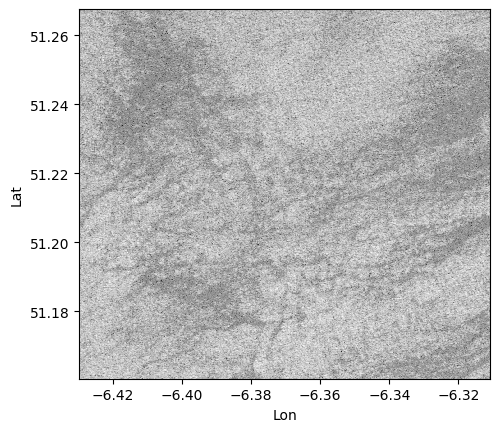

In [ ]:
from rasterio.plot import show

fig, ax = plt.subplots(1)
show(im[0], cmap='gray', interpolation="nearest", ax=ax, transform=im.transform)
ax.grid(False)
# ax.set_title(f"Predicted Map at iteration: {ii}")
ax.set_ylabel("Lat")
ax.set_xlabel("Lon")

## Load the Data

In [15]:
import rasterio as rio
# im_path = "D:\Bristol-AssenSAR-Project\Codes\Sentinel data download\S1 data\S1A_IW_GRDH_1SDV_20230924T181435_20230924T181500_050473_06141A_178A_COG.SAFE\measurement\s1a-iw-grd-vv-20230924t181435-20230924t181500-050473-06141a-001-cog.tiff"
im_path = "D:\Bristol-AssenSAR-Project\Codes\Sentinel data download\S1 data\S1A_IW_GRDH_1SDV_20230909T064020_20230909T064045_050247_060C68_5C3D.SAFE\measurement\s1a-iw-grd-vh-20230909t064020-20230909t064045-050247-060c68-002.tiff"

im=rio.open(im_path)

Text(0.5, 0, 'Lon')

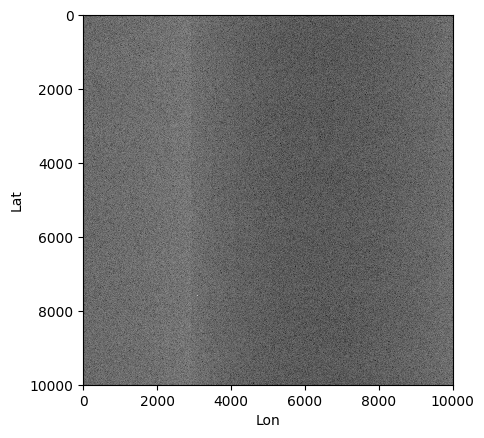

In [17]:
from rasterio.plot import show
subset = im.read(1, window=((5000, 15000), (15000, 25000)))

fig, ax = plt.subplots(1)
show(10*np.log10(subset), cmap='gray', interpolation="nearest", ax=ax, transform=im.transform)
ax.grid(False)
# ax.set_title(f"Predicted Map at iteration: {ii}")
ax.set_ylabel("Lat")
ax.set_xlabel("Lon")